<a href="https://colab.research.google.com/github/GiovanniPasq/agentic-rag-for-dummies/blob/main/notebooks/evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Evaluation

This notebook evaluates the **Agentic RAG for Dummies** system with a small curated QA dataset built from the Markdown corpus and scored with [RAGAS](https://docs.ragas.io/).

The evaluation uses exactly five metrics:

| Metric | Family | What it measures |
|---|---|---|
| **Answer Accuracy** | [NVIDIA metric](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/nvidia_metrics/#answer-accuracy) | Agreement between the generated answer and the reference answer |
| **Context Relevance** | [NVIDIA metric](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/nvidia_metrics/#context-relevance) | Whether retrieved chunks are pertinent to the user query |
| **Response Groundedness** | [NVIDIA metric](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/nvidia_metrics/#response-groundedness) | Whether response claims are supported by retrieved contexts |
| **Context Precision** | Retrieval metric | Whether relevant retrieved chunks are ranked ahead of irrelevant chunks |
| **Context Recall** | Retrieval metric | Whether the retrieved contexts cover the information needed by the reference answer |

Evaluation flow:

1. Load curated QA records from `notebooks/data/curated_ragas_qa.json`.
2. Run each question through the agentic RAG system and save the outputs to `ragas_evaluation_dataset.csv`.
3. Reuse the saved CSV when rerunning evaluation, so the RAG does not need to answer the same questions again.
4. Call each RAGAS metric directly with `await scorer.ascore(...)` and average the scores at the end.

RAGAS can also generate synthetic testsets with `TestsetGenerator.generate_with_langchain_docs(...)` as shown in the [official testset generation guide](https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/#choose-your-llm). The curated JSON dataset is easier to inspect, reproduce, and correct. A human-annotated dataset can better capture semantic nuance, acceptable answer variants, and document-specific interpretation rules.

---
### 📄 Markdown Documents Used
- `javascript_tutorial.md` — JavaScript Tutorial
- `blockchain.md` — Blockchain for Beginners
- `fortinet.md` — Fortinet FortiGate Security Target

> **Prerequisites:** The vector store must already be built (run the ingestion pipeline or the main `agentic_rag.ipynb` first). The local judge is `granite4.1:3b`: `ollama pull granite4.1:3b`.


## 1. Install Dependencies

In [ ]:
import os

REQ_PATH = "requirements.txt" if os.path.exists("requirements.txt") else "../requirements.txt"
!pip install -qU -r {REQ_PATH}

## 2. Imports & Configuration

The app answer model generates the response; the RAGAS judge model scores it. Keeping them different reduces self-grading bias and gives a more independent signal. It does not make the score objective, but it avoids asking the same model to grade its own answer.

RAGAS collection metrics require a modern structured-output LLM. Ollama exposes an OpenAI-compatible API, so the judge stays local while RAGAS talks to it through the OpenAI client.


In [ ]:
import os
import sys
import ast
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm


# RAGAS 0.4.3 imports a legacy path during startup.
# The guard only prevents that import failure; evaluation still uses local Ollama.
import types

try:
    import langchain_community.chat_models.vertexai  # noqa: F401
except ModuleNotFoundError:
    vertexai_module = types.ModuleType("langchain_community.chat_models.vertexai")

    class ChatVertexAI:
        pass

    vertexai_module.ChatVertexAI = ChatVertexAI
    sys.modules["langchain_community.chat_models.vertexai"] = vertexai_module

from ragas.metrics.collections import (
    AnswerAccuracy,
    ContextRelevance,
    ResponseGroundedness,
    ContextPrecision,
    ContextRecall,
)
from openai import AsyncOpenAI
from ragas.llms import llm_factory

# Keep the judge separate from the app answer model to reduce self-evaluation bias.
ANSWER_MODEL = "qwen3:4b-instruct-2507-q4_K_M"
JUDGE_MODEL = "granite4.1:3b"
ollama_client = AsyncOpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama",  # required by the client, ignored by Ollama
)
ragas_llm = llm_factory(
    JUDGE_MODEL,
    client=ollama_client,
    temperature=0,
)

print(f"✅ Answer model under test: {ANSWER_MODEL}")
print(f"✅ RAGAS judge model: {JUDGE_MODEL}")

## 3. Import the RAG System

We import directly from the `rag_agent` package — no need to have the main notebook running in the same kernel.

**Project structure expected:**
```
project/
├── rag_agent/
│   ├── __init__.py
│   ├── graph.py          ← create_agent_graph()
│   ├── graph_state.py
│   ├── nodes.py
│   ├── edges.py
│   ├── tools.py          ← ToolFactory
│   ├── prompts.py
│   └── schemas.py
├── db/
│   └── parent_store_manager.py
├── config.py             ← LLM, embeddings, Qdrant client, paths
└── utils.py
```

> Adjust `PROJECT_ROOT` if you run this notebook from a different directory.

In [ ]:
import os, sys

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
PROJECT_ROOT = "." if IN_COLAB else "../project"  # adjust if needed
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from core.rag_system import RAGSystem

rag = RAGSystem()
rag.initialize()

agent_graph = rag.agent_graph
child_vector_store = rag.vector_db.get_collection(rag.collection_name)

print("✅ RAG system ready")

### 3b. `query_rag` helper

Runs a single question through the full agentic pipeline and returns the answer together
with the child chunks retrieved by a post-hoc similarity search (used as `contexts` by RAGAS).

In [4]:
from langchain_core.messages import HumanMessage
import config as project_config

def query_rag(question: str) -> dict:
    rag.reset_thread()   # evaluate each query independently
    config = rag.get_config()
    result = agent_graph.invoke({"messages": [HumanMessage(content=question)]}, config)
    answer = result["messages"][-1].content

    retrieved_docs = child_vector_store.similarity_search(
        question,
        k=project_config.DEFAULT_RETRIEVAL_K,
        score_threshold=project_config.RETRIEVAL_SCORE_THRESHOLD,
    )
    contexts = [doc.page_content for doc in retrieved_docs]

    return {"answer": answer, "contexts": contexts}

## 4. Curated Evaluation Dataset

This section creates a compact evaluation dataset from `notebooks/data/curated_ragas_qa.json`.

Each record contains:

- `question`: what the user asks
- `reference`: the expected human-written answer
- `markdown_file`: the source document
- `context_phrases`: short anchors used to extract the reference context from Markdown

The final RAGAS dataset contains **30 QA pairs**: 10 from each Markdown document. Keeping the data in JSON makes the notebook cleaner and lets students inspect or improve the evaluation set without touching the notebook logic.


In [ ]:
MARKDOWN_DIR_CANDIDATES = [Path("markdown_docs"), Path("../markdown_docs")]
MARKDOWN_DIR = next((path for path in MARKDOWN_DIR_CANDIDATES if path.exists()), None)
if MARKDOWN_DIR is None:
    searched = ", ".join(str(path.resolve()) for path in MARKDOWN_DIR_CANDIDATES)
    raise FileNotFoundError(f"No markdown_docs directory found. Searched: {searched}")

md_paths = sorted(MARKDOWN_DIR.glob("*.md"))
if not md_paths:
    raise FileNotFoundError(f"No markdown files found in {MARKDOWN_DIR.resolve()}")

doc_texts = {path.name: path.read_text(encoding="utf-8") for path in md_paths}

required_docs = {"javascript_tutorial.md", "blockchain.md", "fortinet.md"}
missing_docs = required_docs - set(doc_texts)
if missing_docs:
    raise FileNotFoundError(f"Missing expected markdown files: {sorted(missing_docs)}")


def extract_context(markdown_file: str, phrases: list[str], window: int = 1400) -> str:
    """Return a compact source-grounded context around the first matching phrase."""
    text = doc_texts[markdown_file]
    lower_text = text.lower()
    match_positions = [
        lower_text.find(phrase.lower())
        for phrase in phrases
        if lower_text.find(phrase.lower()) >= 0
    ]
    center = min(match_positions) if match_positions else 0
    start = max(0, center - window // 3)
    end = min(len(text), center + window)
    return text[start:end].strip()


qa_path_candidates = [
    Path("notebooks/data/curated_ragas_qa.json"),
    Path("data/curated_ragas_qa.json"),
]
qa_path = next((path for path in qa_path_candidates if path.exists()), None)
if qa_path is None:
    searched = ", ".join(str(path.resolve()) for path in qa_path_candidates)
    raise FileNotFoundError(f"No curated QA dataset found. Searched: {searched}")

curated_records = json.loads(qa_path.read_text(encoding="utf-8"))
for record in curated_records:
    record["reference_contexts"] = [
        extract_context(record["markdown_file"], record["context_phrases"])
    ]

curated_df = pd.DataFrame(curated_records)
curated_df.to_csv("ragas_curated_testset.csv", index=False)

print(f"Loaded {len(md_paths)} markdown files.")
print(f"✅ Curated QA records ready: {len(curated_records)} samples")
print("✅ Saved to ragas_curated_testset.csv")

### 4b. Inspect the Curated Dataset

In [ ]:
print(curated_df.shape)
try:
    display(curated_df[["source", "question", "reference"]])
except NameError:
    print(curated_df[["source", "question", "reference"]].to_string(index=False))

## 5. Run the RAG Pipeline on Curated Questions

> ⚠️ This cell queries the RAG once per curated question. It may take several minutes depending on your local LLM.

If `ragas_evaluation_dataset.csv` already exists, you can skip this section and load the saved RAG outputs in section 6.


In [ ]:
if "curated_records" not in globals():
    raise RuntimeError("Run section 4 first to load curated_records.")

results = []

for record in tqdm(curated_records, total=len(curated_records), desc="Querying RAG"):
    question = record["question"]
    reference = record["reference"]
    reference_contexts = record["reference_contexts"]
    source = record["source"]

    try:
        rag_output = query_rag(question)
        results.append({
            "source": source,
            "question": question,
            "answer": rag_output["answer"],
            "contexts": rag_output["contexts"],
            "ground_truth": reference,
            "reference_contexts": reference_contexts,
        })
    except Exception as e:
        print(f"❌ Error for: '{question[:60]}...' — {e}")
        results.append({
            "source": source,
            "question": question,
            "answer": "",
            "contexts": [],
            "ground_truth": reference,
            "reference_contexts": reference_contexts,
        })

print(f"\n✅ Done. {len(results)} results collected.")

## 6. Load or Prepare Saved RAG Outputs

The metrics only need the question, generated answer, retrieved contexts, and reference answer. This section loads those fields from `ragas_evaluation_dataset.csv` when available, or prepares them from the freshly generated `results`.


In [ ]:
def parse_context_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (SyntaxError, ValueError):
            pass
        return [value]
    return []


def find_existing_csv(*paths):
    for candidate in paths:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return None


evaluation_csv_path = find_existing_csv(
    "./ragas_evaluation_dataset.csv",
    "notebooks/ragas_evaluation_dataset.csv",
)

if evaluation_csv_path is not None:
    print(f"✅ Loading saved RAG outputs from {evaluation_csv_path}")
    ragas_df = pd.read_csv(evaluation_csv_path)
    ragas_df["retrieved_contexts"] = ragas_df["retrieved_contexts"].apply(parse_context_list)
    ragas_df["reference_contexts"] = ragas_df["reference_contexts"].apply(parse_context_list)

    curated_by_question = {
        record["question"]: record
        for record in globals().get("curated_records", [])
    }

    results = []
    for _, row in ragas_df.iterrows():
        metadata = curated_by_question.get(row["user_input"], {})
        results.append(
            {
                "source": metadata.get("source", "saved_csv"),
                "question": row["user_input"],
                "answer": row["response"],
                "ground_truth": row["reference"],
                "contexts": row["retrieved_contexts"],
                "reference_contexts": row["reference_contexts"],
            }
        )
else:
    if "results" not in globals():
        raise RuntimeError(
            "No saved ragas_evaluation_dataset.csv found. Run section 5 first to query the RAG."
        )

    ragas_df = pd.DataFrame(
        {
            "user_input": r["question"],
            "retrieved_contexts": r["contexts"],
            "reference_contexts": r.get("reference_contexts", []),
            "response": r["answer"],
            "reference": r["ground_truth"],
        }
        for r in results
    )

print(f"✅ Evaluation rows ready: {len(ragas_df)}")

In [ ]:
ragas_df.to_csv("./ragas_evaluation_dataset.csv", index=False)
print("✅ Saved RAG outputs to ragas_evaluation_dataset.csv")

## 7. Compute RAGAS Metrics

### Metric definitions

| Metric | Family | Description | Range |
|---|---|---|---|
| **Answer Accuracy** | NVIDIA metric | Agreement between generated answer and reference answer | 0–1 |
| **Context Relevance** | NVIDIA metric | Relevance of retrieved contexts to the query | 0–1 |
| **Response Groundedness** | NVIDIA metric | Support of response claims in retrieved contexts | 0–1 |
| **Context Precision** | Retrieval metric | Whether relevant chunks are ranked higher than irrelevant chunks | 0–1 |
| **Context Recall** | Retrieval metric | Whether retrieved contexts cover the reference answer | 0–1 |

Each scorer follows the RAGAS collection-metric examples: create the metric, call `await scorer.ascore(...)`, store the score, and average at the end.


In [ ]:
metric_scorers = {
    "answer_accuracy": AnswerAccuracy(llm=ragas_llm),
    "context_relevance": ContextRelevance(llm=ragas_llm),
    "response_groundedness": ResponseGroundedness(llm=ragas_llm),
    "context_precision": ContextPrecision(llm=ragas_llm),
    "context_recall": ContextRecall(llm=ragas_llm),
}


async def score_answer(row, scorers):
    retrieved_contexts = row["retrieved_contexts"]

    metric_inputs = {
        "answer_accuracy": {
            "user_input": row["user_input"],
            "response": row["response"],
            "reference": row["reference"],
        },
        "context_relevance": {
            "user_input": row["user_input"],
            "retrieved_contexts": retrieved_contexts,
        },
        "response_groundedness": {
            "response": row["response"],
            "retrieved_contexts": retrieved_contexts,
        },
        "context_precision": {
            "user_input": row["user_input"],
            "reference": row["reference"],
            "retrieved_contexts": retrieved_contexts,
        },
        "context_recall": {
            "user_input": row["user_input"],
            "retrieved_contexts": retrieved_contexts,
            "reference": row["reference"],
        },
    }

    scores = {}
    for metric_name, scorer in scorers.items():
        try:
            result = await scorer.ascore(**metric_inputs[metric_name])
            scores[metric_name] = result.value
            tqdm.write(f"   {metric_name}: {result.value:.3f}")
        except Exception as exc:
            scores[metric_name] = np.nan
            tqdm.write(f"   {metric_name}: failed ({exc})")

    return scores


print("🔄 Running RAGAS metrics...")
score_rows = []
for idx, row in tqdm(ragas_df.iterrows(), total=len(ragas_df), desc="Evaluating"):
    tqdm.write(f"\n[{idx + 1}/{len(ragas_df)}] {row['user_input'][:90]}")
    score_rows.append(await score_answer(row, metric_scorers))

scores_df = pd.DataFrame(score_rows)
print("\n✅ Done!")
print(scores_df.mean(numeric_only=True).round(3).to_string())
scores_df.head()

🔄 Running RAGAS metrics...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


[1/30] What is JavaScript designed for, and why is it easy to implement in web pages?


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

   answer_accuracy: 1.000


...

Evaluating:  97%|█████████▋| 29/30 [09:26<00:22, 22.30s/it]

   context_precision: 1.000


Evaluating: 100%|██████████| 30/30 [09:33<00:00, 19.11s/it]

   context_recall: 1.000

✅ Done!
answer_accuracy          0.800
context_relevance        0.558
response_groundedness    0.808
context_precision        0.644
context_recall           0.573


,answer_accuracy,context_relevance,response_groundedness,context_precision,context_recall
0,1.00,1.00,1.00,1.0,1.000000
1,1.00,0.50,1.00,1.0,1.000000
2,1.00,0.25,0.75,1.0,1.000000
3,0.75,0.50,1.00,0.0,0.058824
4,1.00,0.25,0.50,0.0,0.000000


## 8. Results as a DataFrame

In [ ]:
df = pd.concat([ragas_df.reset_index(drop=True), scores_df], axis=1)

df.insert(0, "source", [r["source"] for r in results])
df["question"] = df["user_input"]
df["answer"] = df["response"]
df["ground_truth"] = df["reference"]

metric_cols = [
    "answer_accuracy",
    "context_relevance",
    "response_groundedness",
    "context_precision",
    "context_recall",
]

missing_metric_cols = [col for col in metric_cols if col not in df.columns]
if missing_metric_cols:
    print(f"⚠️ Missing metric columns: {missing_metric_cols}")

metric_cols = [col for col in metric_cols if col in df.columns]
df.head()

,source,user_input,retrieved_contexts,reference_contexts,response,reference,answer_accuracy,context_relevance,response_groundedness,context_precision,context_recall,question,answer,ground_truth
0,javascript_tutorial.pdf,"What is JavaScript designed for, and why is it...",[--- end of page.page_number=1 ---\n\n## **Abo...,[--- end of page.page_number=1 ---\n\n## **Abo...,JavaScript is designed for creating network-ce...,JavaScript is a lightweight interpreted progra...,1.00,1.00,1.00,1.0,1.000000,"What is JavaScript designed for, and why is it...",JavaScript is designed for creating network-ce...,JavaScript is a lightweight interpreted progra...
1,javascript_tutorial.pdf,"Who is the JavaScript tutorial intended for, a...",[## **Audience** \nThis tutorial has been pre...,[--- end of page.page_number=1 ---\n\n## **Abo...,The JavaScript tutorial is intended for beginn...,The tutorial is intended for JavaScript beginn...,1.00,0.50,1.00,1.0,1.000000,"Who is the JavaScript tutorial intended for, a...",The JavaScript tutorial is intended for beginn...,The tutorial is intended for JavaScript beginn...
2,javascript_tutorial.pdf,What does the JavaScript tutorial disclaimer s...,[We strive to update the contents of our websi...,"[ites q** \n\nFor this tutorial, it is assumed...",The JavaScript tutorial disclaimer states the ...,The disclaimer says the content belongs to Tut...,1.00,0.25,0.75,1.0,1.000000,What does the JavaScript tutorial disclaimer s...,The JavaScript tutorial disclaimer states the ...,The disclaimer says the content belongs to Tut...
3,javascript_tutorial.pdf,Which topics are included in Part 1 of the Jav...,[PART 1: JAVASCRIPT BASICS ......................,[................................................,The topics included in Part 1 of the JavaScrip...,Part 1 includes JavaScript basics such as over...,0.75,0.50,1.00,0.0,0.058824,Which topics are included in Part 1 of the Jav...,The topics included in Part 1 of the JavaScrip...,Part 1 includes JavaScript basics such as over...
4,javascript_tutorial.pdf,What control-flow topics does the JavaScript t...,[57 The continue Statement ......................,[erators ........................................,The control-flow topics covered in the JavaScr...,"The tutorial lists if-else statements, switch-...",1.00,0.25,0.50,0.0,0.000000,What control-flow topics does the JavaScript t...,The control-flow topics covered in the JavaScr...,"The tutorial lists if-else statements, switch-..."


## 9. Aggregate Scores per Source

In [10]:
agg = df.groupby("source")[metric_cols].mean().round(3)
agg.loc["OVERALL"] = df[metric_cols].mean().round(3)

print("=" * 70)
print(" RAGAS Scores — Mean per Source")
print("=" * 70)
print(agg.to_string())
print("=" * 70)

 RAGAS Scores — Mean per Source
                         answer_accuracy  context_relevance  response_groundedness  context_precision  context_recall
source                                                                                                               
blockchain.pdf                      0.80              0.625                  0.700              0.583           0.530
fortinet.pdf                        0.75              0.550                  0.900              0.750           0.634
javascript_tutorial.pdf             0.85              0.500                  0.825              0.600           0.556
OVERALL                             0.80              0.558                  0.808              0.644           0.573


## 10. Visualisations

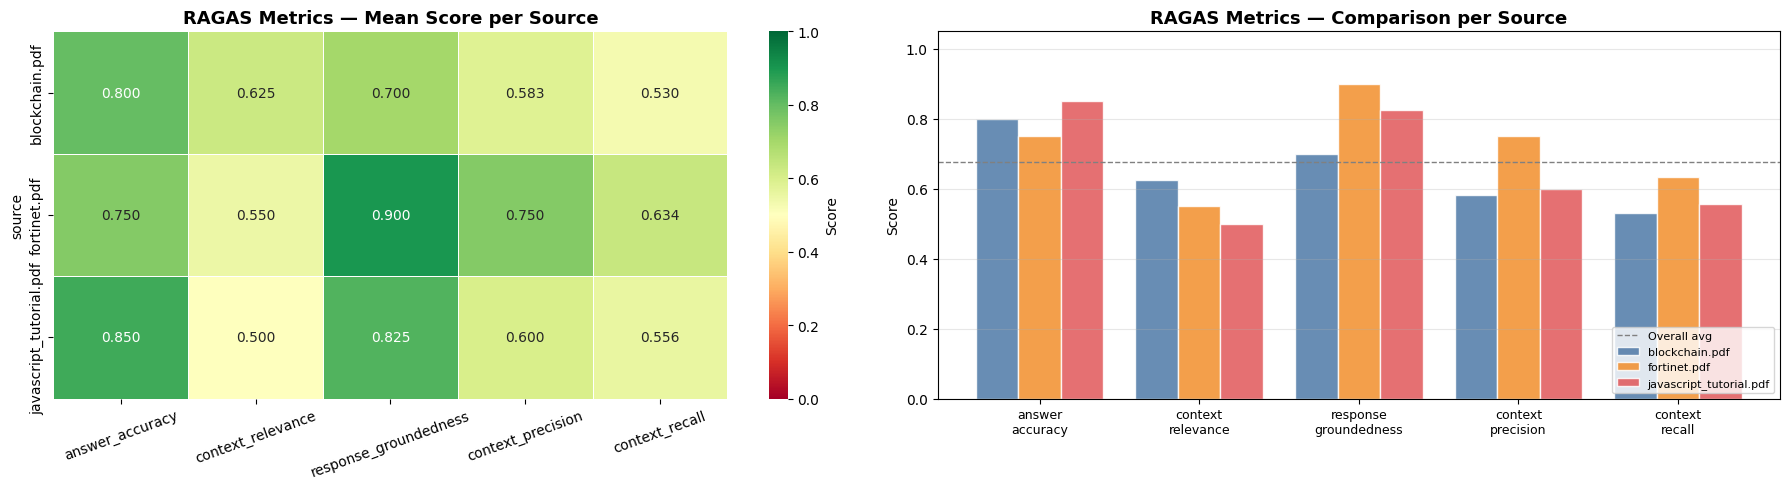

📊 Chart saved to rag_evaluation_heatmap_bar.png


In [11]:
# ── 10A. Heatmap + Grouped bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Heatmap
sns.heatmap(
    agg.drop("OVERALL"),
    ax=axes[0],
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Score"},
)
axes[0].set_title("RAGAS Metrics — Mean Score per Source", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

# Grouped bar chart
sources = agg.drop("OVERALL").index.tolist()
x = range(len(metric_cols))
width = 0.8 / max(len(sources), 1)
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]

for i, src in enumerate(sources):
    vals = agg.loc[src, metric_cols].values
    axes[1].bar(
        [xi + i * width for xi in x],
        vals,
        width=width,
        label=src,
        color=colors[i % len(colors)],
        alpha=0.85,
        edgecolor="white",
    )

axes[1].axhline(
    y=agg.loc["OVERALL", metric_cols].mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Overall avg",
)
axes[1].set_xticks([xi + width * max(len(sources) - 1, 0) / 2 for xi in x])
axes[1].set_xticklabels([c.replace("_", "\n") for c in metric_cols], fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("RAGAS Metrics — Comparison per Source", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("rag_evaluation_heatmap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved to rag_evaluation_heatmap_bar.png")

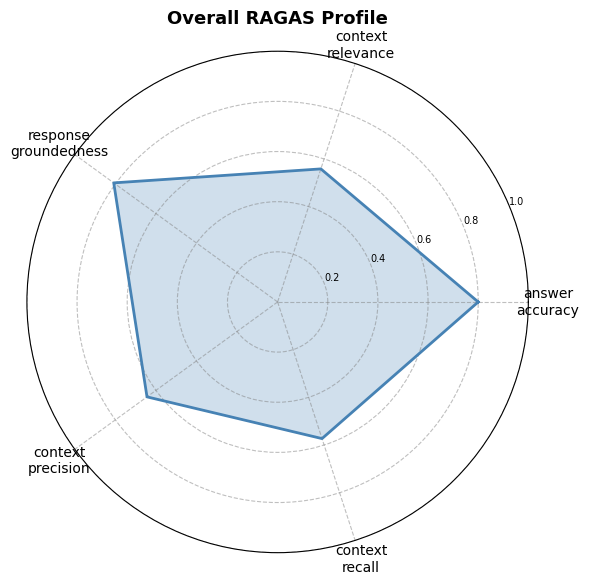

📊 Radar chart saved to rag_evaluation_radar.png


In [12]:
# ── 10B. Radar chart — Overall profile ───────────────────────────────────────
labels       = [c.replace("_", "\n") for c in metric_cols]
overall_vals = agg.loc["OVERALL", metric_cols].values.tolist()
overall_vals += overall_vals[:1]   # close the polygon

angles = np.linspace(0, 2 * np.pi, len(metric_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, overall_vals, color="steelblue", linewidth=2)
ax.fill(angles, overall_vals, color="steelblue", alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
ax.set_title("Overall RAGAS Profile", fontsize=13, fontweight="bold", pad=20)
ax.grid(color="grey", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("rag_evaluation_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Radar chart saved to rag_evaluation_radar.png")

## 11. Save Results to CSV

In [13]:
output_path = "rag_evaluation_results.csv"
df[["source", "question", "answer", "ground_truth"] + metric_cols].to_csv(
    output_path, index=False
)
print(f"✅ Full results saved to {output_path}")

agg.to_csv("rag_evaluation_summary.csv")
print("✅ Summary saved to rag_evaluation_summary.csv")

✅ Full results saved to rag_evaluation_results.csv
✅ Summary saved to rag_evaluation_summary.csv


## 12. Interpretation Guide

```
┌───────────────────────────────────────────────────────────────────────────┐
│  Metric                  │ Score < 0.4   │ 0.4-0.7 (OK) │ > 0.7 (Good)   │
│───────────────────────────────────────────────────────────────────────────│
│  Answer Accuracy         │ Wrong answer  │ Partial match│ Matches ref     │
│  Context Relevance       │ Off-topic ctx │ Some focus   │ Focused context │
│  Response Groundedness   │ Unsupported   │ Partly based │ Fully grounded  │
│  Context Precision       │ Noisy rank    │ Some noise   │ Relevant first  │
│  Context Recall          │ Missing info  │ Partial info │ Complete info   │
└───────────────────────────────────────────────────────────────────────────┘
```

### How to improve each metric

| Low metric | Likely cause | Fix |
|---|---|---|
| Answer Accuracy | Generated answer does not match the reference | Improve prompts, retrieval coverage, or use a stronger answer model |
| Context Relevance | Retrieved chunks are off-topic | Increase `score_threshold`, improve query rewriting, or tune embeddings |
| Response Groundedness | Answer includes claims not supported by retrieved chunks | Strengthen grounding instructions and reduce unsupported synthesis |
| Context Precision | Relevant chunks are not ranked first | Reduce `k`, increase `score_threshold`, or add reranking |
| Context Recall | Required information was not retrieved | Lower `score_threshold`, increase `k`, improve embeddings, or split documents differently |

### Agentic metrics available in RAGAS, not implemented here

RAGAS also provides [agentic/tool-use metrics](https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/agents/) for workflows where you want to judge the agent trace rather than only the final RAG answer:

| Metric | Use when |
|---|---|
| `ToolCallAccuracy` | You have expected tool calls and need exact sequence/argument matching |
| `ToolCallF1` | You want softer precision/recall scoring over tool calls |
| `AgentGoalAccuracyWithReference` | You have a reference final outcome for the agent task |
| `AgentGoalAccuracyWithoutReference` | You want the judge to decide whether the goal was achieved without a reference |
| `TopicAdherence` | You need to verify whether a conversation stays within expected topics |

They are not implemented in this notebook because they require multi-turn traces, expected tool calls, or goal-state annotations. This notebook evaluates the final RAG answer and retrieved contexts with single-turn RAG metrics only.

### How the agent graph affects scores

| Component | Metric impacted | Tuning lever |
|---|---|---|
| `search_child_chunks` `score_threshold` | Context Precision / Recall / Relevance | Raise = more precise, lower = more recall |
| `MAX_TOOL_CALLS` / `MAX_ITERATIONS` | Answer Accuracy / Context Recall | Higher = more research, slower |
| `compress_context` | Response Groundedness / Answer Accuracy | Compression can drop details needed by the final answer |
| Query rewriting | Context Relevance / Context Recall | Better rewrites improve retrieval coverage and focus |